In [46]:
import pandas as pd
import numpy as np
import json
import umap
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import adjusted_rand_score


In [51]:
df = pd.read_json("../data/supervise_myth_clusters.json", orient="records", lines=True)
df_tropes = pd.read_json("../data/binary_myth_tropes.json", orient="records", lines=True)
df_influenced = pd.read_json("../data/myth_influence.json", orient="records", lines=True)
cluster_map = json.load(open("../data/theme_map.json"))
df_myth_tropes =pd.read_json("../data/binary_myth_trope.json", orient="records", lines=True)


df_influenced_series = df_influenced[0]
df_myth_tropes_series = df_myth_tropes[0]

#print(df['cluster'].head())
#print(cluster_map)
print(df.columns)

Index(['id', 'text', 'type', 'source', 'imdb_title', 'imdb_year',
       'imdb_genres', 'inferred_media_type', 'combined_text',
       'has_semantic_match', 'has_lexical_match',
       'has_sentence_myth_trope_hit', 'max_trope_similarity', 'myth_hit_count',
       'myth_theme', 'cluster', 'has_myth_hit', 'has_myth_trope_hit',
       'agglo_cluster'],
      dtype='object')


In [21]:
X_features = df_tropes.drop(columns='cluster', errors='ignore')

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
X_umap = reducer.fit_transform(X_features)

c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


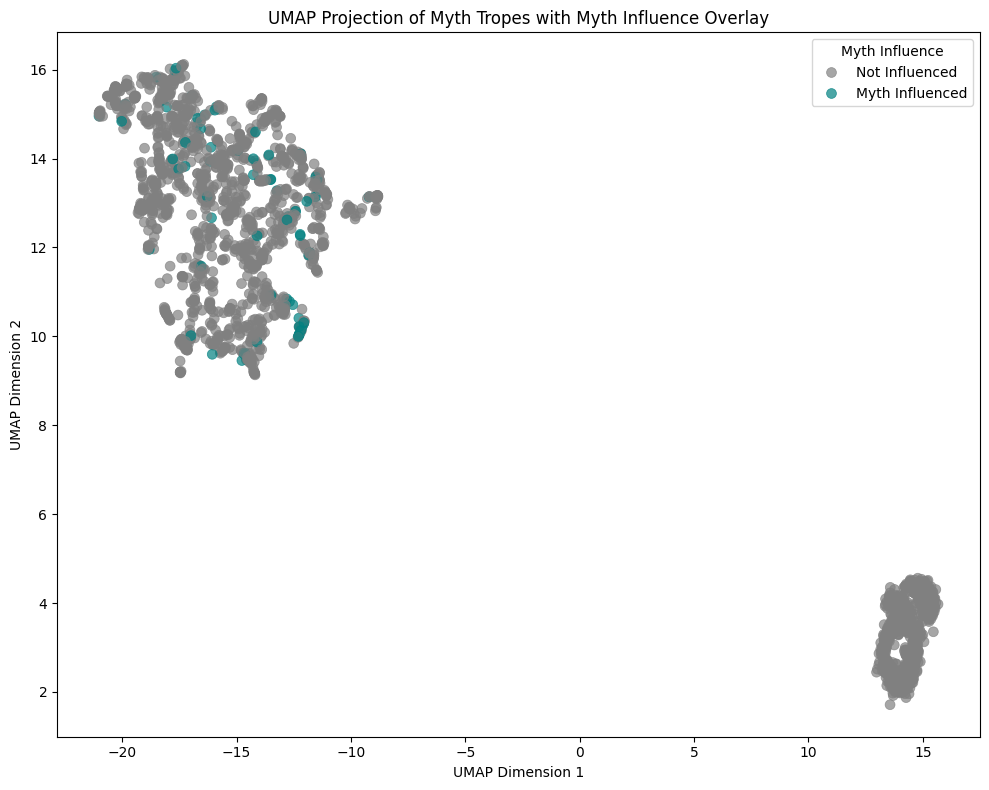

In [22]:
plt.figure(figsize=(10, 8))

# Use myth influence as hue
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=df_influenced_series.map({True: "Myth Influenced", False: "Not Influenced"}),
    palette=["gray", "teal"],
    s=50,
    alpha=0.7,
    edgecolor=None
)

plt.title("UMAP Projection of Myth Tropes with Myth Influence Overlay")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Myth Influence", loc="best")
plt.tight_layout()
plt.show()

In [23]:
sparsity = 1.0 - (np.count_nonzero(X_features) / X_features.size)
print(f"Sparsity of X_features: {sparsity:.2%}")

Sparsity of X_features: 87.61%


In [24]:
reducer = umap.UMAP(n_neighbors=40, min_dist=0.4, metric='cosine', random_state=42)
X_umap = reducer.fit_transform(X_features)

c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


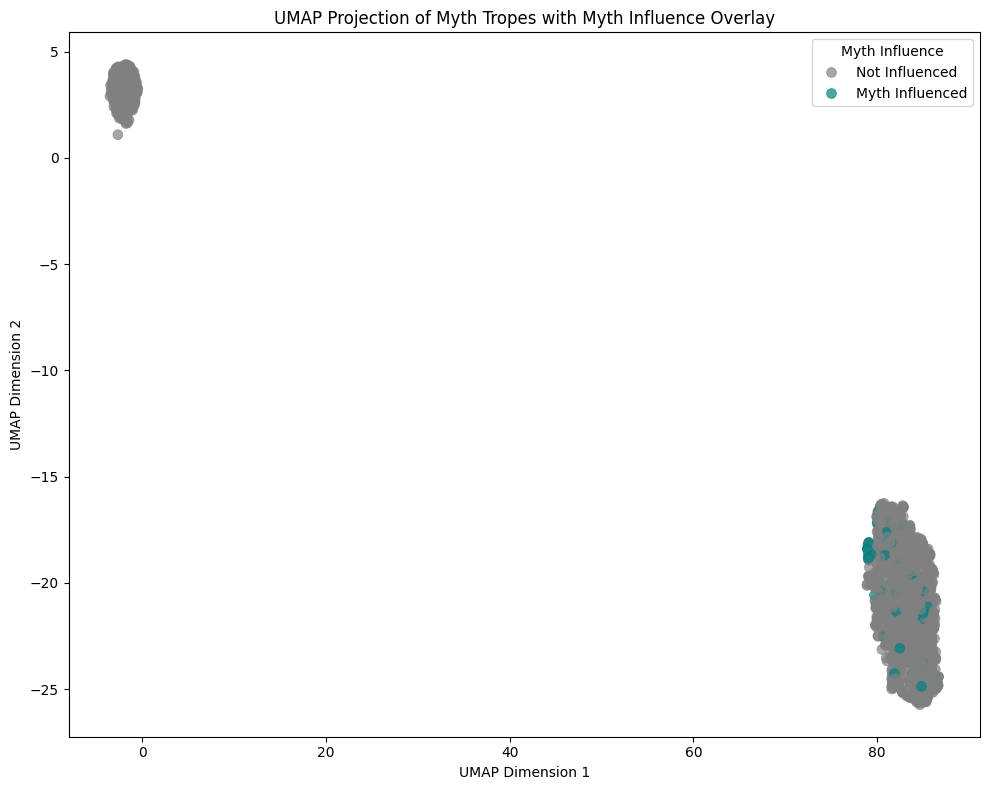

In [25]:
plt.figure(figsize=(10, 8))

# Use myth influence as hue
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=df_influenced_series.map({True: "Myth Influenced", False: "Not Influenced"}),
    palette=["gray", "teal"],
    s=50,
    alpha=0.7,
    edgecolor=None
)

plt.title("UMAP Projection of Myth Tropes with Myth Influence Overlay")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Myth Influence", loc="best")
plt.tight_layout()
plt.show()

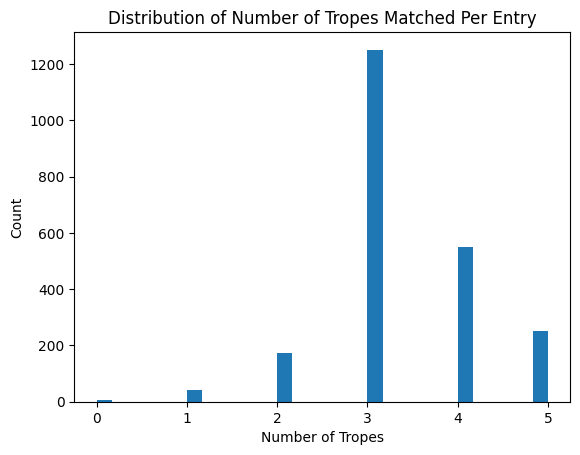

In [26]:
row_sums = X_features.sum(axis=1)
plt.hist(row_sums, bins=30)
plt.title("Distribution of Number of Tropes Matched Per Entry")
plt.xlabel("Number of Tropes")
plt.ylabel("Count")
plt.show()

In [27]:
tropes_sums = X_features.sum(axis=0).sort_values(ascending=False)
print(tropes_sums.head(10))

Reincarnation       1316
Animal_Beast        1003
TheTrickster         984
BigBad               485
DarkestHour          373
TheChosenOne         297
SpiritAdvisor        280
DealWithTheDevil     257
DragonsAreDivine     220
GodOfChaos           219
dtype: int64


In [29]:
tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_features)

# Run UMAP on X_tfidf
reducer = umap.UMAP(n_neighbors=40, min_dist=0.4, metric='cosine', random_state=42)
X_umap_tfidf = reducer.fit_transform(X_tfidf)

c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


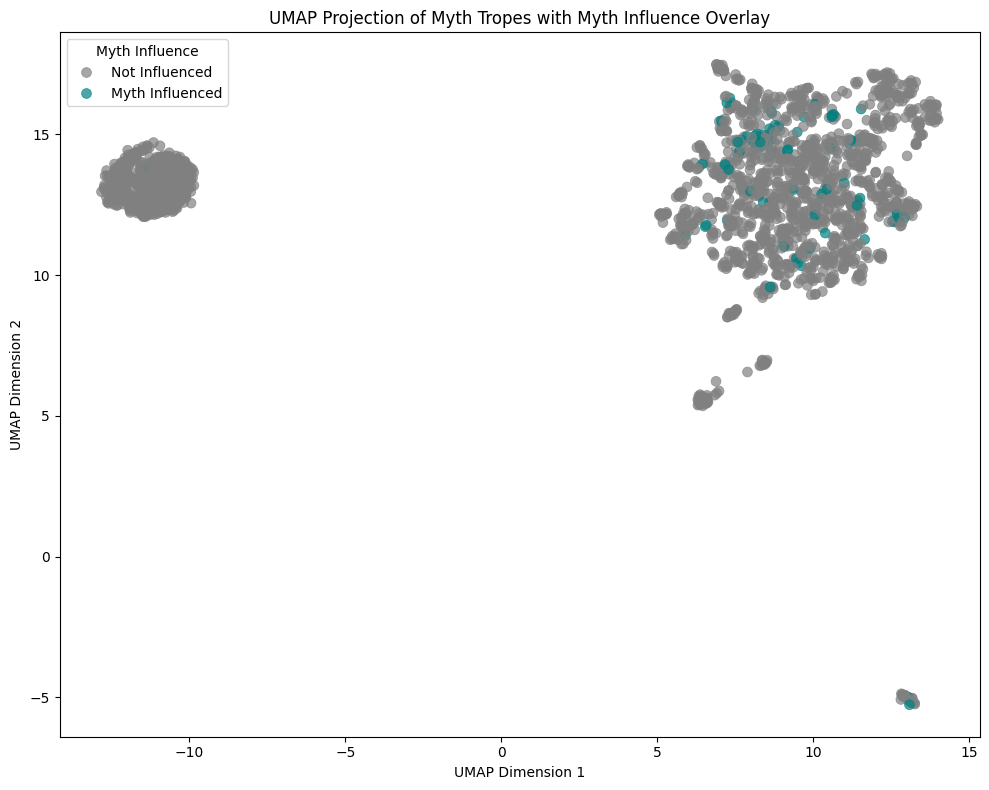

In [30]:
plt.figure(figsize=(10, 8))

# Use myth influence as hue
sns.scatterplot(
    x=X_umap_tfidf[:, 0],
    y=X_umap_tfidf[:, 1],
    hue=df_influenced_series.map({True: "Myth Influenced", False: "Not Influenced"}),
    palette=["gray", "teal"],
    s=50,
    alpha=0.7,
    edgecolor=None
)

plt.title("UMAP Projection of Myth Tropes with Myth Influence Overlay")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Myth Influence", loc="best")
plt.tight_layout()
plt.show()

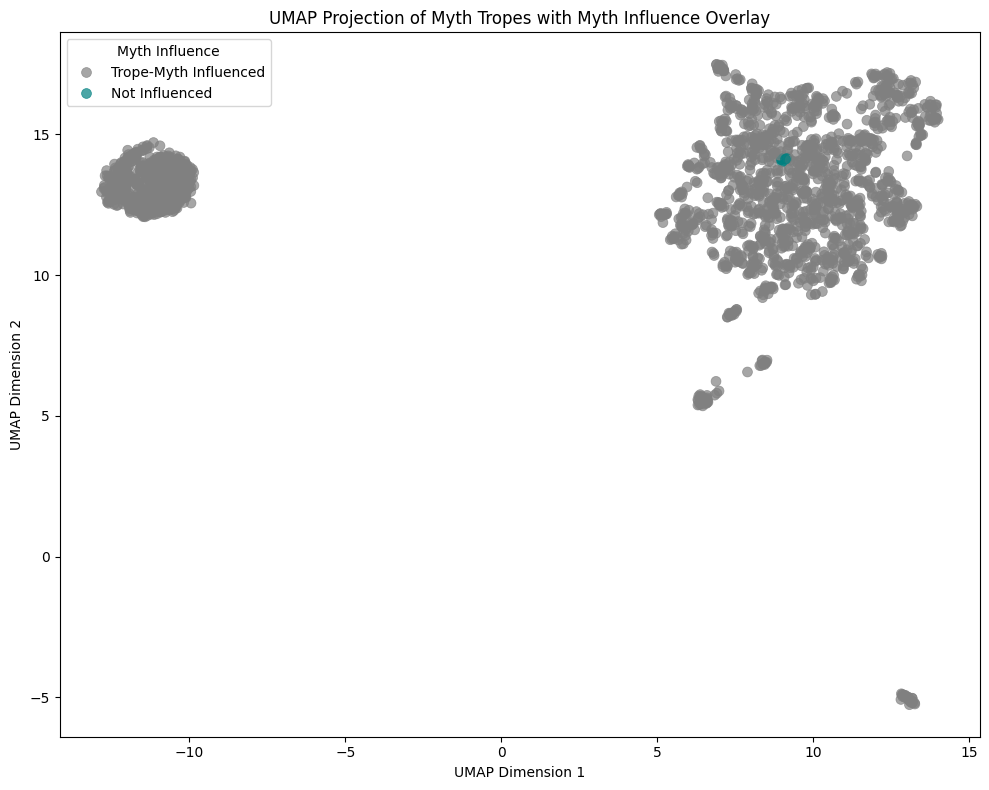

In [35]:
plt.figure(figsize=(10, 8))

# Use myth influence as hue
sns.scatterplot(
    x=X_umap_tfidf[:, 0],
    y=X_umap_tfidf[:, 1],
    hue=df_myth_tropes_series.map({True: "Trope-Myth Influenced", False: "Not Influenced"}),
    palette=["gray", "teal"],
    s=50,
    alpha=0.7,
    edgecolor=None
)

plt.title("UMAP Projection of Myth Tropes with Myth Influence Overlay")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Myth Influence", loc="best")
plt.tight_layout()
plt.show()

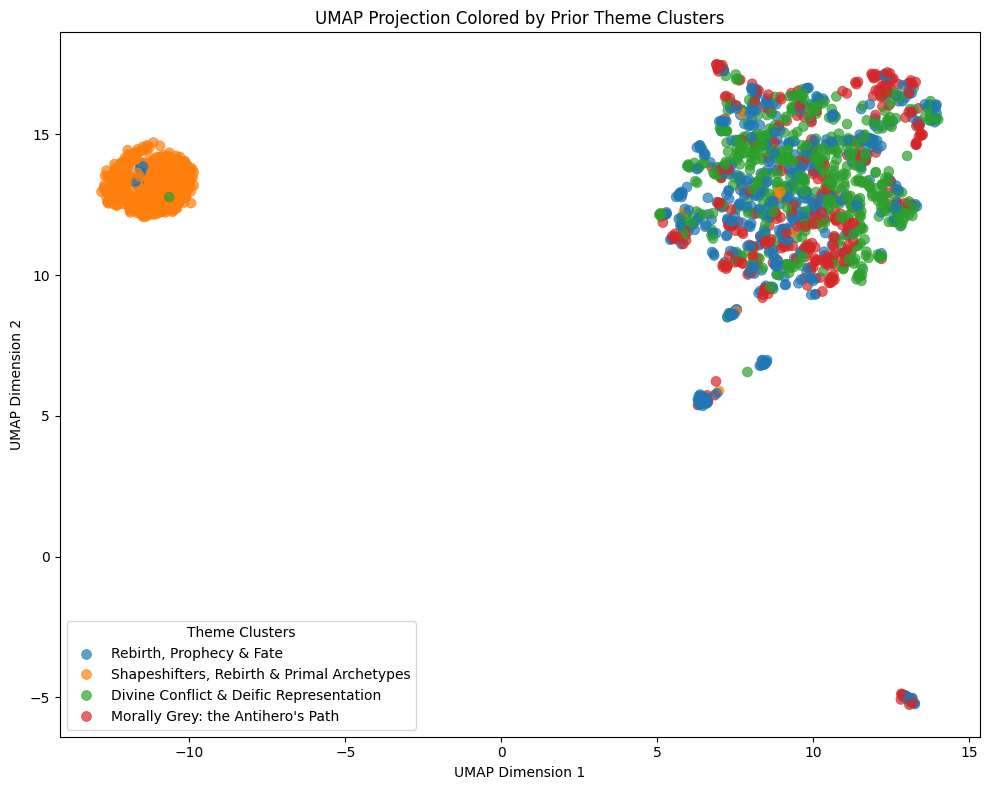

In [43]:

cluster_map = {
    0: 'Divine Conflict & Deific Representation',
    1: 'Shapeshifters, Rebirth & Primal Archetypes',
    2: 'Rebirth, Prophecy & Fate',
    3: "Morally Grey: the Antihero's Path"
}

theme_map = df_tropes['cluster'].map(cluster_map)


plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_umap_tfidf[:, 0],
    y=X_umap_tfidf[:, 1],
    hue=theme_map,
    palette="tab10",
    s=50,
    alpha=0.7,
    edgecolor=None
)
plt.title("UMAP Projection Colored by Prior Theme Clusters")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Theme Clusters", loc="best")
plt.tight_layout()
plt.show()

In [55]:
# Create and fit HDBSCAN clusterer
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,       # smaller captures finer subclusters
    min_samples=5,             # affects noise labeling; lower = fewer noise points
    metric='euclidean',        # default for UMAP outputs
    cluster_selection_method='eom'  # default, or try 'leaf' for finer clusters
)

hdb_labels = clusterer.fit_predict(X_umap_tfidf)

# Add labels to your DataFrame for easy analysis if desired:
df_tropes['hdbscan_cluster'] = hdb_labels
print(df_tropes['hdbscan_cluster'].head())

0    6
1    0
2    0
3    0
4    6
Name: hdbscan_cluster, dtype: int64


c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


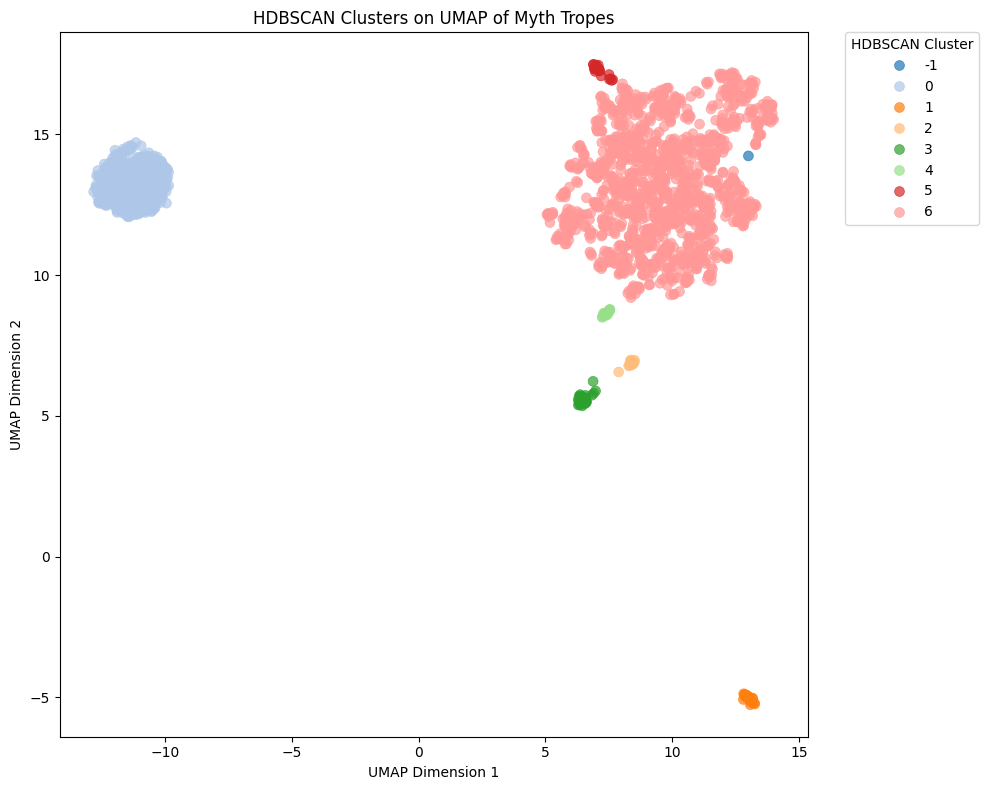

In [56]:

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_umap_tfidf[:, 0],
    y=X_umap_tfidf[:, 1],
    hue=hdb_labels,
    palette="tab20",
    s=50,
    alpha=0.7,
    edgecolor=None
)
plt.title("HDBSCAN Clusters on UMAP of Myth Tropes")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="HDBSCAN Cluster", loc="best", bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.tight_layout()
plt.show()

In [57]:
ari_theme = adjusted_rand_score(df_tropes['cluster'], hdb_labels)
print(f"ARI with prior theme clusters: {ari_theme:.4f}")

ARI with prior theme clusters: 0.4649


In [58]:
ari_myth = adjusted_rand_score(df_influenced.iloc[:, 0], hdb_labels)
print(f"ARI with myth influence labels: {ari_myth:.4f}")

ARI with myth influence labels: -0.0193


In [59]:
print(pd.Series(hdb_labels).value_counts().sort_index())

-1       1
 0     803
 1      28
 2      15
 3      37
 4      16
 5      24
 6    1351
Name: count, dtype: int64


In [60]:
print(df.index.equals(df_tropes.index))

print(df.columns)
print(df_tropes.columns)

ari_hdb_agglo = adjusted_rand_score(df['agglo_cluster'], df_tropes['hdbscan_cluster'])
print(f"ARI between HDBSCAN and Agglomerative: {ari_hdb_agglo:.4f}")

True
Index(['id', 'text', 'type', 'source', 'imdb_title', 'imdb_year',
       'imdb_genres', 'inferred_media_type', 'combined_text',
       'has_semantic_match', 'has_lexical_match',
       'has_sentence_myth_trope_hit', 'max_trope_similarity', 'myth_hit_count',
       'myth_theme', 'cluster', 'has_myth_hit', 'has_myth_trope_hit',
       'agglo_cluster'],
      dtype='object')
Index(['AntiHero', 'BigBad', 'BornOfMagic', 'DarkestHour', 'DealWithTheDevil',
       'DragonsAreDivine', 'ElementalEmbodiment', 'FateWorseThanDeath',
       'GodIsFlawed', 'GodIsGood', 'GodOfChaos', 'GodOfTheDead', 'GrimReaper',
       'MoonGod', 'NatureSpirit', 'ProphecyTwist', 'Reincarnation', 'Satan',
       'ShapeshifterShowdown', 'SkyGod', 'SpiritAdvisor', 'TheChosenOne',
       'TheTrickster', 'Trickster God', 'WarGod', 'WhiteMage', 'cluster',
       'Animal_Beast', 'hdbscan_cluster'],
      dtype='object')
ARI between HDBSCAN and Agglomerative: 0.3463
